In [24]:
from ngsolve import *
import numpy as np
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
from ngsolve.meshes import Make1DMesh
from math import isnan
import time
from ngsolve.nonlinearsolvers import Newton

ngsglobals.msg_level = 0
%matplotlib notebook
import warnings
warnings.filterwarnings('ignore')

# Define functions for both methods

## Mixed method

In [12]:
def Mixed(
    n0 = 20,
    m = 2,
    s0 = 3,
    order = 1,
    dt0 = 0.01,
    tstart = Parameter(0),
    tstop = 4,
    plot = 0,
):
    tau = Parameter(dt0)
    
    k = 1/(m+1)
    rho_ex0 = (tstart+1)**(-k) * (s0 - k*(m-1)/(2*m) * x**2/(tstart+1)**(2*k))**(1/(m-1))
    rho_ex = IfPos(rho_ex0,rho_ex0,0)
    xmin, xmax = -10,10
        
    mesh = Make1DMesh(n=n0, mapping=lambda x:xmin+(xmax-xmin)*x)
    h0 = (xmax-xmin)/n0
    
    pnts_x = np.linspace(xmin,xmax,n0+1)
    pnts_x0 = np.linspace(xmin+0.5*h0,xmax-0.5*h0,n0)
    
        
    V = L2(mesh) # density
    W = H1(mesh) # velocity
    fes = FESpace([V, W])
    
    (rho, u), (eta, v) = fes.TnT()    
    
    gfu = GridFunction(fes)
    rhoh, uh = gfu.components
    rhoh0 = GridFunction(V) # previous den
    rhoh1 = GridFunction(W) # average den
    
    # the nonlinear operator
    a  = BilinearForm(fes)
    n = specialcf.normal(mesh.dim)
    flux = u*n*IfPos(u*n, rhoh0, 2*rhoh1-rhoh0)
    
    # mass
    a += (rho-rhoh0)/tau*eta*dx
    a += flux*eta*dx(element_boundary=True)
    # vel
    ir = IntegrationRule(points = [(0,0), (1,0)], weights = [1/2, 1/2] )
    a += u*v*dx(intrules={SEGM:ir})    
    p = m/(m-1)*rho**(m-1)
    # linearize pres
#     p = m/(m-1)*rhoh0**(m-1)+ m*rhoh0**(m-2)*(rho-rhoh0)
    a += -p*grad(v)*dx
    
    # only used to set up initial data
    def getU():
        rho0 = rhoh.vec.FV().NumPy()        
        p0 = m/(m-1)*rho0**(m-1)
        uh.vec.FV().NumPy()[1:-1] = (p0[:-1]-p0[1:])/h0
   
    iteration = 0
    # initial data: L2-projection
    rhoh.Set(rho_ex)
    getU()
    rhoh1.Set(rhoh)
        
    if plot == 1:
        fig = plt.figure()
        fig.set_size_inches(6, 4, forward=True)
        ax = fig.add_subplot(111)
        ax.set_ylabel(r'$\rho$, $u$')
        ax.set_xlabel(r'$x$')
        ax.minorticks_on()
        ax.tick_params(direction="in",which='both',axis='both')
        
    
        pnts_rho_ex = [rho_ex(mesh(x)) for x in pnts_x] 
        pnts_rho = rhoh.vec.FV().NumPy()

        line1, = ax.plot(pnts_x0,rhoh.vec,'rs',label=r'$\rho$')
        line2, = ax.plot(pnts_x, uh.vec,'k.-',label=r'$u$')
        line3, = ax.plot(pnts_x, pnts_rho_ex,'k--',label=r'$\rho_{exact}$')
        ax.legend(frameon=0,loc='upper left')
        fig.canvas.draw()
        
    with TaskManager():
        while tstart.Get() < tstop - tau.Get()/2:
            iteration += 1
            dt = tau.Get()
            tstart.Set(tstart.Get()+dt)                
            # apply RHS
            rhoh0.vec.data = rhoh.vec
            rhoh1.Set(rhoh)
            # The linearized scheme only need 1 Newton iteration 
            it = Newton(a, gfu, printing=False, maxit=100, maxerr=1e-6)
            
            iteration += 1
            if plot == 1 and iteration % 100 == 0:
                pnts_rho_ex = [rho_ex(mesh(x)) for x in pnts_x] 
                line1.set_ydata(rhoh.vec)
                line2.set_ydata(uh.vec)
                line3.set_ydata(pnts_rho_ex)
                
                
                fig.canvas.draw()
    sub0 = IfPos((x-5)*(x+5), 0, 1)
    err = sqrt(Integrate(sub0*(rhoh-rho_ex)**2*dx(intrules={SEGM:ir})  , mesh))
    if plot == 1:
        pnts_rho_ex = [rho_ex(mesh(x)) for x in pnts_x] 
        line1.set_ydata(rhoh.vec)
        line2.set_ydata(uh.vec)
        line3.set_ydata(pnts_rho_ex)
            

        fig.canvas.draw()

    return err


        

## Log density

In [13]:
def logDensity(
n0 = 20,
m = 2,
s0 = 3,
order = 1,
dt0 = 1e-2,
tstart = Parameter(0),
tstop = 4,
plot = 0,):
    
    def myNewton(xL,xR,uh,uh0,rhok,rhouk,damp0=1,tol0=1e-8):
        uh.vec.data = uh0.vec

        activeDofs[:] = 0
        xL1 = xL-1+(xL==0)
        xR1 = xR+1-(xR==nx)
        activeDofs[xL1:xR1+1] = True

        uh.vec[xL1] = uh.vec[xL]
        uh.vec[xR1] = uh.vec[xR]

        rhok.vec.FV().NumPy()[xL1:xR1+1] = np.exp(uh.vec.FV().NumPy()[xL1:xR1+1])
        rhouk.vec.FV().NumPy()[xL1:xR1+1] = rhok.vec.FV().NumPy()[xL1:xR1+1]*uh.vec.FV().NumPy()[xL1:xR1+1]
        count = 0
        energy0 = (uh.vec.FV().NumPy()[xL1:xR1+1]-1).dot(rhok.vec.FV().NumPy()[xL1:xR1+1])
        tol = abs(energy0)*tol0

        while True:
            count += 1
            damp = min(damp0*count,1)
            tmp.data = rhok.vec

            a.Assemble()
            f.Assemble()
            uh.vec.data = a.mat.Inverse(freedofs = activeDofs, inverse="sparsecholesky")*f.vec
            rhok.vec.FV().NumPy()[xL1:xR1+1] = np.exp(uh.vec.FV().NumPy()[xL1:xR1+1])
            rhouk.vec.FV().NumPy()[xL1:xR1+1] = rhok.vec.FV().NumPy()[xL1:xR1+1]*uh.vec.FV().NumPy()[xL1:xR1+1]
            energy1 = (uh.vec.FV().NumPy()[xL1:xR1+1]-1).dot(rhok.vec.FV().NumPy()[xL1:xR1+1])
            err = abs(energy1-energy0)
            energy0 = energy1
            if err < tol :
                break
            if np.isnan(err):
                print(count,"FAILED")
                stop
        return count 

    with TaskManager():
        nx = n0
        dt = Parameter(dt0)
        tstart = Parameter(0)
        minVal = -40
        order = 1
        eps0 = 0
        
        k = 1/(m+1)   
        xmin = -10
        xmax = 10
        tend = tstop
        t0 = 1
        # reference solution
        k = 1/(m+1)
        rho_ex0 = (tstart+1)**(-k) * (s0 - k*(m-1)/(2*m) * x**2/(tstart+1)**(2*k))**(1/(m-1))
        rhoex = IfPos(rho_ex0,rho_ex0,0)
        xmin, xmax = -10,10


            
        
        mesh = Make1DMesh(n = nx, mapping=lambda x:xmin+(xmax-xmin)*x)
        uex = log(rhoex)
        fes = H1(mesh,order=order)
        uh = GridFunction(fes)
        
        # Used to store data of previous iteration
        uh0 = GridFunction(fes)
        rho0 = GridFunction(fes)
        # Used in Newton's iterations
        rhok = GridFunction(fes)
        rhouk = GridFunction(fes)
        
        rho0.vec[:] = 0
        rhok.vec[:] = 0


        u, v = fes.TnT()

        ir = IntegrationRule(points = [(0,0), (1,0)], weights = [1/2, 1/2] )


        # Linearized: e^u = e^(u_k) (1+u-u_k)
        a = BilinearForm(fes)
        a += m*rho0**m*grad(u)*grad(v)*dx(intrules={SEGM:ir})
        a += rhok*u*v/dt*dx(intrules={SEGM:ir})

        f = LinearForm(fes)
        f += (rhouk-rhok+rho0)*v/dt*dx(intrules={SEGM:ir})
        
        # Initial data interpolation
        h0 = (xmax-xmin)/nx
        uh0.Set(uex)

        # Returns a boolean array
        pos = uh0.vec.FV().NumPy() > minVal
        # Left/Right nodes
        xL, xR = np.where(pos)[0][0], np.where(pos)[0][-1]

        # rho_0
        rho0.vec.FV().NumPy()[pos] = np.exp(uh0.vec.FV().NumPy()[pos])

        activeDofs = BitArray(fes.ndof)
        tmp = rhok.vec.CreateVector()
        
        step = 0
        
        pnts_x = np.linspace(xmin,xmax,nx+1)  
        
        if plot == 1:
            fig = plt.figure()
            fig.set_size_inches(6, 4, forward=True)
            ax = fig.add_subplot(111)
            ax.set_ylabel(r'$\rho$, $u$')
            ax.set_xlabel(r'$x$')
            ax.minorticks_on()
            ax.tick_params(direction="in",which='both',axis='both')


            pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
            pnts_rho = rhok.vec.FV().NumPy()
    
            line1, = ax.plot(pnts_x,pnts_rho,'rs',label=r'$\rho$')
            label3 = r'$\rho_{exact}$'
            line3, = ax.plot(pnts_x, pnts_rho_ex,'k--',label=label3)
            ax.legend(frameon=0,loc='upper left')
            fig.canvas.draw()
        

        
        while tstart.Get() < tend-dt.Get()/2:
            tstart.Set(tstart.Get()+dt.Get())
            step += 1
            
            ct = myNewton(xL,xR,uh,uh0,rhok, rhouk)
            xL1 = xL-1+(xL == 0)
            xR1 = xR+1-(xR == nx)
            
            if uh.vec[xL1]>minVal:
                xL = xL1
            if uh.vec[xR1]>minVal:
                xR = xR1
            
            uh0.vec.data = uh.vec
            rho0.vec.FV().NumPy()[xL:xR+1] = np.exp(uh0.vec.FV().NumPy()[xL:xR+1])
            
            if plot == 1 and step % 100 == 0:
                pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
                line1.set_ydata(rhok.vec)
                line3.set_ydata(pnts_rho_ex)
                fig.canvas.draw()
            
        
            #print("\r Time: %.3f step: %3i, ITER: %3i %.3f %3i %.3f %3i %.3e"%(
             #   tstart.Get(), step, ct, uh0.vec[xL], xL, uh0.vec[xR], xR, err),end="")
        if plot == 1:
            pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
            line1.set_ydata(rhok.vec)
            if tend == 0: line1.set_ydata(pnts_rho_ex)
            line3.set_ydata(pnts_rho_ex)


            fig.canvas.draw()
        sub0 = IfPos((x-5)*(x+5), 0, 1)
        err = sqrt(Integrate(sub0*(rhok-rhoex)**2*dx(intrules={SEGM:ir}), mesh))
        return err


# Solution at t = 0 for m = 4

<IPython.core.display.Javascript object>


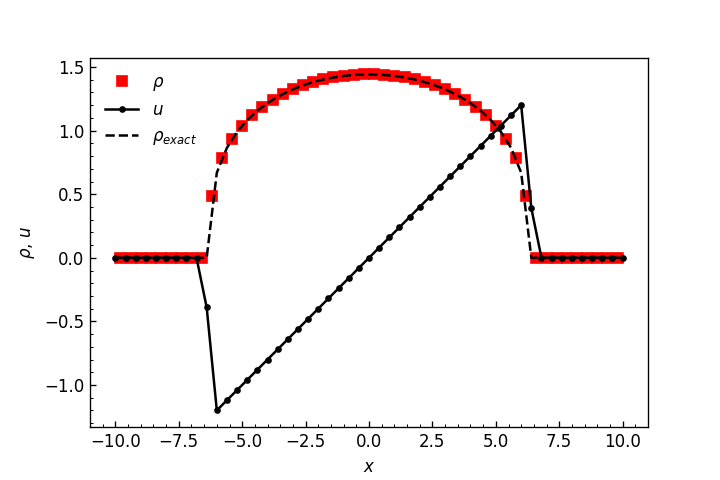

<IPython.core.display.Javascript object>


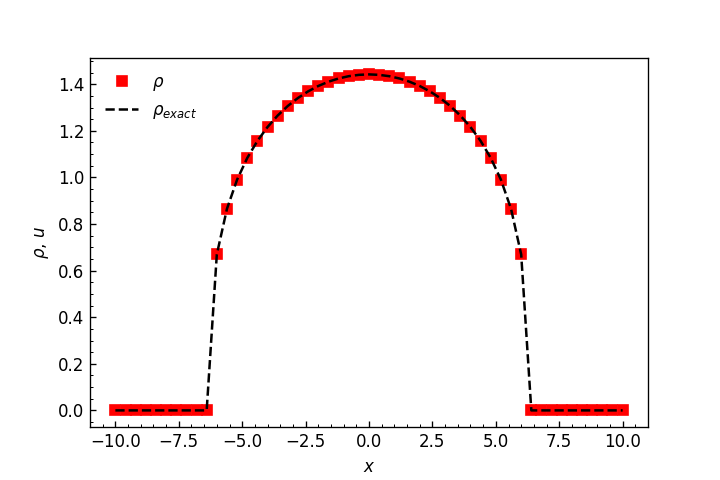

In [17]:
m=4
nx = 50
dt = 1e-2
e=Mixed(m=m,dt0=dt,tstart=Parameter(0),tstop = 0,n0 = nx, plot=1)
e=logDensity(m=m,dt0=dt,tstart=Parameter(0),tstop = 0,n0 = nx, plot=1)

# Solution at $t=1$ for $m=4$

Error is calculated in [-5,5]

<IPython.core.display.Javascript object>


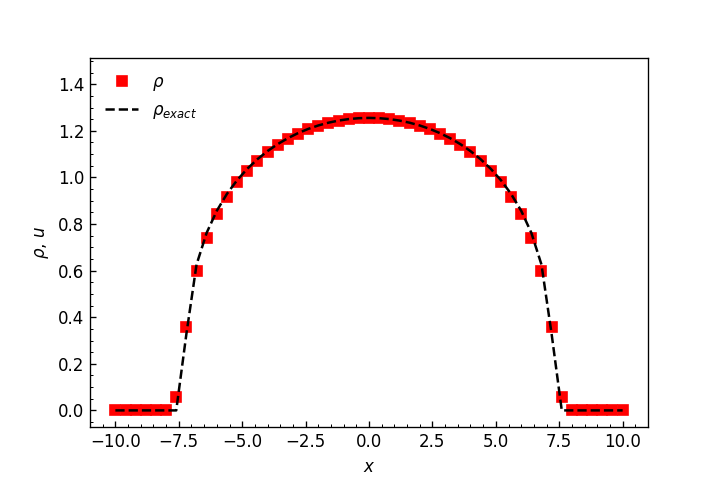

<IPython.core.display.Javascript object>


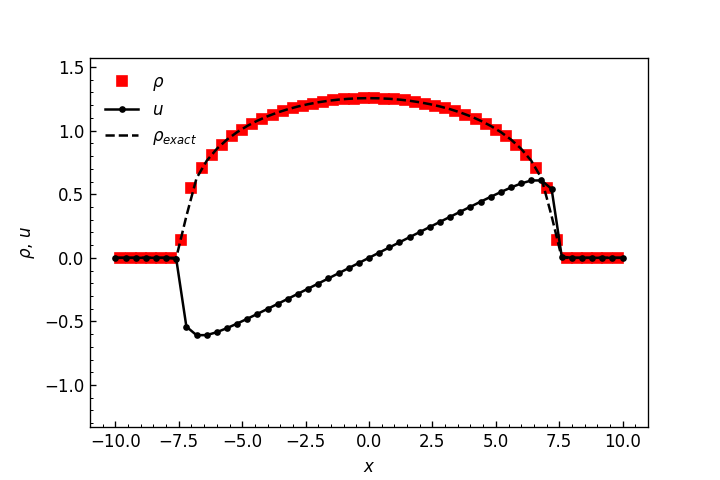

0.02435084812414122

In [5]:
m=4
nx = 50
dt = 1e-2
logDensity(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=1)
Mixed(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=1)

# Spacetime accuracy test for $m =3$ 

## Mixed method

In [124]:
print('nx \t dt \t error \t order')
eo = np.nan
m=3
for cc in range(3):
    dt = 1e-3/4**cc
    nx = 40*2**cc
    e=Mixed(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=0)
    print('{} \t {} \t {} \t {}'.format(nx,dt,e,np.log2(eo/e)))
    eo = e

nx 	 dt 	 error 	 order
40 	 0.001 	 0.05251421988238239 	 nan
80 	 0.00025 	 0.027790575728883504 	 0.9181124081718878
160 	 6.25e-05 	 0.014471915376011666 	 0.9413398457306044


## Log entropy

In [125]:
print('nx \t dt \t error \t order')
eo = np.nan
m=3
for cc in range(3):
    dt = 1e-3/4**cc
    nx = 40*2**cc
    e=logDensity(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=0)
    print('{} \t {} \t {} \t {}'.format(nx,dt,e,np.log2(eo/e)))
    eo = e

nx 	 dt 	 error 	 order
40 	 0.001 	 0.017652168969647553 	 nan
80 	 0.00025 	 0.006148566510484671 	 1.5215234603605923
160 	 6.25e-05 	 0.002191588115313759 	 1.488273411511103


# Spacetime accuracy test for $m = 4$

The mixed method requires finer grids due to lower spatial accuracy. This is why the order obtained is smaller.

## Mixed method

In [123]:
print('nx \t dt \t error \t order')
eo = np.nan
m=4
for cc in range(3):
    dt = 1e-3/4**cc
    nx = 40*2**cc
    e=Mixed(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=0)
    print('{} \t {} \t {} \t {}'.format(nx,dt,e,np.log2(eo/e)))
    eo = e

nx 	 dt 	 error 	 order
40 	 0.001 	 0.02910416271296339 	 nan
80 	 0.00025 	 0.017810568055620916 	 0.7084919828922431
160 	 6.25e-05 	 0.00826336143095772 	 1.1079328546651404


## Log entropy

In [122]:
print('nx \t dt \t error \t order')
eo = np.nan
m=4
for cc in range(3):
    dt = 1e-3/4**cc
    nx = 40*2**cc
    e=logDensity(m=m,dt0=dt,tstart=Parameter(0),tstop = 1,n0 = nx, plot=0)
    print('{} \t {} \t {} \t {}'.format(nx,dt,e,np.log2(eo/e)))
    eo = e

nx 	 dt 	 error 	 order
40 	 0.001 	 0.04716775666772371 	 nan
80 	 0.00025 	 0.011424567311248543 	 2.0456614605334336
160 	 6.25e-05 	 0.005661567297427902 	 1.012866130161788


# Alternate implementation of log density method

In [ ]:
def logDensity2(
n0 = 20,
m = 2,
s0 = 3,
order = 1,
dt0 = 1e-2,
tstart = Parameter(0),
tstop = 4,
plot = 0,
cutOff = 1e-14):
    
    def myNewton(damp0=1, tol0 = 1e-8):
        uh.vec.data = uh0.vec
        rhok.vec.FV().NumPy()[:] = np.exp(uh.vec.FV().NumPy()[:])
        # set -inf to zero for simplicity!!! FIXME LATER
        pos = rhok.vec.FV().NumPy()==0
        uh.vec.FV().NumPy()[pos] = 0 
        rhouk.vec.FV().NumPy()[:] = rhok.vec.FV().NumPy()[:]*uh.vec.FV().NumPy()[:]

        count = 0
        ener0 = (uh.vec.FV().NumPy()[:]-1).dot(rhok.vec.FV().NumPy()[:])

        tol = abs(ener0)*tol0 # relative tolerance
        while True:
            count += 1
            # hack zero
            a.Assemble()
            f.Assemble()
            if count==1: # locate active Dofs
                rows,cols,vals = a.mat.COO()
                A = sp.csr_matrix((vals,(rows,cols)))
                active = A.diagonal()>cutOff

                activeDofs[:] = 0
                # THIS IS SUPER SLOW...
                for i in range(len(active)):
                    if active[i]:
                        activeDofs[i] = 1



            uh.vec.data = a.mat.Inverse(freedofs = activeDofs,inverse="sparsecholesky")*f.vec
            rhok.vec.FV().NumPy()[active] = np.exp(uh.vec.FV().NumPy()[active])
            rhouk.vec.FV().NumPy()[active] = rhok.vec.FV().NumPy()[active]*uh.vec.FV().NumPy()[active]


            ener1 = (uh.vec.FV().NumPy()[active]-1).dot(rhok.vec.FV().NumPy()[active])
            err = abs(ener1-ener0)
            ener0 = ener1
            if err < tol:
                uh.vec.FV().NumPy()[~active] = -np.inf
                break
            if np.isnan(err) or count==30:
                print(count,"FAILED")
                stop 

        return count 


    with TaskManager():
        nx = n0
        dt = Parameter(dt0)
        tstart = Parameter(0)
        minVal = -40
        order = 1
        eps0 = 0
        
        k = 1/(m+1)   
        xmin = -10
        xmax = 10
        tend = tstop
        t0 = 1
        # initial condition
        k = 1/(m+1)
        rho_ex0 = (tstart+1)**(-k) * (s0 - k*(m-1)/(2*m) * x**2/(tstart+1)**(2*k))**(1/(m-1))
        rhoex = IfPos(rho_ex0,rho_ex0,0)
        xmin, xmax = -10,10


        mesh = Make1DMesh(n = nx, mapping=lambda x:xmin+(xmax-xmin)*x)
        uex = log(rhoex)
        fes = H1(mesh,order=order)
        uh = GridFunction(fes)
        
        # Used to store data of previous iteration
        uh0 = GridFunction(fes)
        rho0 = GridFunction(fes)
        # Used in Newton's iterations
        rhok = GridFunction(fes)
        rhouk = GridFunction(fes)
        
        rho0.vec[:] = 0
        rhok.vec[:] = 0


        u, v = fes.TnT()

        ir = IntegrationRule(points = [(0,0), (1,0)], weights = [1/2, 1/2] )


        # Linearized: e^u = e^(u_k) (1+u-u_k)
        a = BilinearForm(fes)
        a += m*rho0**m*grad(u)*grad(v)*dx(intrules={SEGM:ir})
        a += rhok*u*v/dt*dx(intrules={SEGM:ir})

        f = LinearForm(fes)
        f += (rhouk-rhok+rho0)*v/dt*dx(intrules={SEGM:ir})
        
        # Initial data interpolation
        h0 = (xmax-xmin)/nx
        uh0.Set(uex)

        # Avoid NAN values
        pos = uh0.vec.FV().NumPy() > -40
        uh0.vec.FV().NumPy()[~pos] = -np.inf
        rho0.vec.FV().NumPy()[:] = np.exp(uh0.vec.FV().NumPy())

        activeDofs = BitArray(fes.ndof)

        
        pnts_x = np.linspace(xmin,xmax,nx+1)  
        
        if plot == 1:
            fig = plt.figure()
            fig.set_size_inches(6, 4, forward=True)
            ax = fig.add_subplot(111)
            ax.set_ylabel(r'$\rho$, $u$')
            ax.set_xlabel(r'$x$')
            ax.minorticks_on()
            ax.tick_params(direction="in",which='both',axis='both')
            

            pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
            pnts_rho = rhok.vec.FV().NumPy()
    
            line1, = ax.plot(pnts_x,pnts_rho,'r--',label=r'$\rho$')
            line3, = ax.plot(pnts_x, pnts_rho_ex,'k--',label=r'$\rho_{exact}$')
            ax.legend(frameon=0,loc='upper left')
            fig.canvas.draw()

        step = 0
        while tstart.Get() < tend-dt.Get()/2:
            tstart.Set(tstart.Get()+dt.Get())
            step += 1
            ct = myNewton()

            uh0.vec.data = uh.vec
            rho0.vec.FV().NumPy()[:] = np.exp(uh0.vec.FV().NumPy())
            pnts_rhoex = np.array([rhoex(mesh(x)) for x in pnts_x])
           
            
            
            if plot == 1 and step % 50 == 0:
                pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
                line1.set_ydata(rhok.vec)
                line3.set_ydata(pnts_rho_ex)
                fig.canvas.draw()
            
        
        
        
        if plot: 
            pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
            line1.set_ydata(rhok.vec)
            line3.set_ydata(pnts_rho_ex)
            fig.canvas.draw()
    sub0 = IfPos((x-5)*(x+5), 0, 1)
    err = sqrt(Integrate(sub0*(rhok-rhoex)**2*dx(intrules={SEGM:ir}), mesh))
    return err